# 🙋🏻‍♂️ **Predict Customer Churn**

Welcome to the 2026 Kaggle Playground Series! We plan to continue in the spirit of previous playgrounds, providing interesting and approachable datasets for our community to practice their machine learning skills, and anticipate a competition each month.

Your Goal: Predict the likelihood of customer churn.

## 🌐 **1. Import libraries**

In [161]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

## 🫳 **2. Taking data**

In [162]:
warnings.filterwarnings('ignore')

In [163]:
df_train = pd.read_csv('/content/train.csv')
df_test = pd.read_csv('/content/test.csv')

In [164]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  object 
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  object 
 4   Dependents        594194 non-null  object 
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  object 
 7   MultipleLines     594194 non-null  object 
 8   InternetService   594194 non-null  object 
 9   OnlineSecurity    594194 non-null  object 
 10  OnlineBackup      594194 non-null  object 
 11  DeviceProtection  594194 non-null  object 
 12  TechSupport       594194 non-null  object 
 13  StreamingTV       594194 non-null  object 
 14  StreamingMovies   594194 non-null  object 
 15  Contract          594194 non-null  object 
 16  PaperlessBilling  59

## 🍃 **3. Data processing and cleaning**

In [165]:
df_train.dropna(axis = 0, how = 'any', inplace = True)

In [166]:
df_test.dropna(axis = 0, how = 'any', inplace = True)

In [167]:
df_train = pd.get_dummies(df_train, drop_first = True)

In [168]:
df_test = pd.get_dummies(df_test, drop_first = True)

In [169]:
X = df_train.drop('Churn_Yes', axis = 1)

In [170]:
y = df_train['Churn_Yes']

In [171]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, shuffle = True)

## ֎ **4. Training the model with the selection of the best hyperparameters**

In [172]:
hyperparameters = {'max_depth': [6],
                   'min_samples_split': [2],
                   'criterion': ['gini'],
                   'min_samples_leaf': [8],
                   'max_features': ['auto', 'sqrt', 'log2', None]}

In [173]:
grid = GridSearchCV(DecisionTreeClassifier(), hyperparameters, cv = 5, verbose = True, scoring = 'accuracy')
grid.fit(X_train, y_train)

Fitting 5 folds for each of 4 candidates, totalling 20 fits


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini'], 'max_depth': [6],
                         'max_features': ['auto', 'sqrt', 'log2', None],
                         'min_samples_leaf': [8], 'min_samples_split': [2]},
             scoring='accuracy', verbose=True)

In [174]:
print(grid.best_params_)

{'criterion': 'gini', 'max_depth': 6, 'max_features': None, 'min_samples_leaf': 8, 'min_samples_split': 2}


In [175]:
prediction = grid.predict(X_test)

## 🧔🏻 **5. Confusion Matrix**

In [176]:
labels = list(map(str, y.unique()))

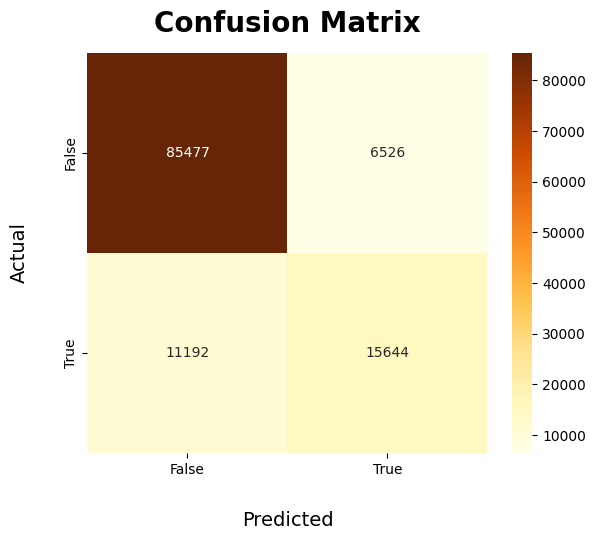

In [177]:
figure = plt.figure(figsize = (5, 4))

matrix_heat = confusion_matrix(y_test, prediction)

axes = figure.add_axes([0, 0, 1, 1])
sns.heatmap(matrix_heat, annot = True, fmt = 'd', cmap = 'YlOrBr')
axes.xaxis.set_ticklabels(labels)
axes.yaxis.set_ticklabels(labels)
axes.set_xlabel('Predicted', labelpad = 25, fontsize = 14)
axes.set_ylabel('Actual', labelpad = 25, fontsize = 14)
axes.set_title('Confusion Matrix', fontweight = 'bold', pad = 15, fontsize = 20)

plt.show()

## 🗣️ **6. Classification Report**

In [178]:
print(classification_report(y_test, prediction))

              precision    recall  f1-score   support

       False       0.88      0.93      0.91     92003
        True       0.71      0.58      0.64     26836

    accuracy                           0.85    118839
   macro avg       0.79      0.76      0.77    118839
weighted avg       0.84      0.85      0.85    118839



## 📶 **7. AUC-ROC**

In [179]:
fpr, tpr, _ = roc_curve(y_test, prediction)

In [180]:
roc_auc = auc(fpr, tpr)

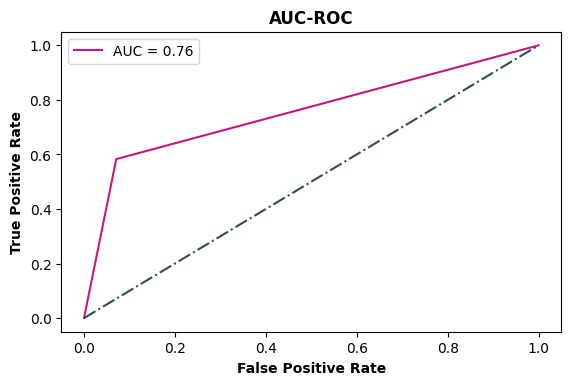

In [181]:
figure = plt.figure(figsize = (5, 3))

axes = figure.add_axes([0, 0, 1, 1])
axes.plot(fpr, tpr, label = f'AUC = {roc_auc:.2f}', color = '#C71585')
axes.plot([0, 1], [0, 1], color = '#2F4F4F', linestyle = '-.')
axes.set_xlabel('False Positive Rate', fontweight = 'bold')
axes.set_ylabel('True Positive Rate', fontweight = 'bold')
axes.set_title('AUC-ROC', fontweight = 'bold')

plt.legend()
plt.show()

## 🎲 **8. Return the probability of customer churn**

In [182]:
churn_probability = grid.predict_proba(df_test)[:, 1]

submission = pd.DataFrame({'id': df_test['id'], 'Churn': churn_probability})

In [184]:
submission.to_csv('submission.csv', index = False)